In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

In [6]:
df = pd.read_csv("vindr/vindr_val.csv")
df

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
1,0c7a38f293d5f5e4846aa4ca6db4daf1,ILD,5,R17,1347.0,245.0,2188.0,2169.0
2,d3637a1935a905b3c326af31389cb846,Aortic enlargement,0,R10,1329.0,743.0,1521.0,958.0
3,321c111713c3ee5385db0effb54ff568,Aortic enlargement,0,R8,1292.0,554.0,1477.0,805.0
4,fb8e11c6b2886b2d41b379e0598669b9,Aortic enlargement,0,R10,1390.0,878.0,1616.0,1163.0
...,...,...,...,...,...,...,...,...
8904,2860567dbd5d3f2597072e0b0e45ccd6,Lung Opacity,7,R8,253.0,1626.0,771.0,1966.0
8905,09b9674023305cb9a0acb367600efffa,Lung Opacity,7,R10,968.0,1020.0,1331.0,1385.0
8906,66332eb5425bcdc6854aae970cc656b9,Nodule/Mass,8,R8,2161.0,1600.0,2308.0,1758.0
8907,22672ab82c290c20b86863291e25ef6c,ILD,5,R9,299.0,664.0,794.0,1508.0


In [5]:
img_dirname = "/data6/rajivporana_scratch/vindr_data/png_train/"
wh_img_dir = "/data6/rajivporana_scratch/vindr_data/wh_proper_train/"

In [24]:
import os
import cv2
import hashlib
from skimage.metrics import structural_similarity as ssim


def compare_images(df, img_dirname, wh_img_dir):
    count =0
    temp = []
    for index, row in df.iterrows():
        image_id = row['image_id']
        img_path1 = os.path.join(img_dirname, row['image_id'] + ".png")  
        img_path2 = os.path.join(wh_img_dir, "png_train_" + row['image_id'] + ".png")
        

        if not os.path.exists(img_path2):
            continue
        img1 = cv2.imread(img_path1)
        img2 = cv2.imread(img_path2)
        img1_resized = cv2.resize(img1, (256, 256))
        img2_resized = cv2.resize(img2, (256,256))

        
        

        img1_gray = cv2.cvtColor(img1_resized, cv2.COLOR_BGR2GRAY)
        img2_gray = cv2.cvtColor(img2_resized, cv2.COLOR_BGR2GRAY)

    # Compute SSIM between the two images
        score, diff = ssim(img1_gray, img2_gray, full=True)
        if score > 0.95:
            count += 1
        else:
            temp.append(image_id)
    return count,temp



In [ ]:
count,temp = compare_images(df,img_dirname, wh_img_dir)


TypeError: cannot unpack non-iterable int object

1127.0 793.0 260.0 253.0


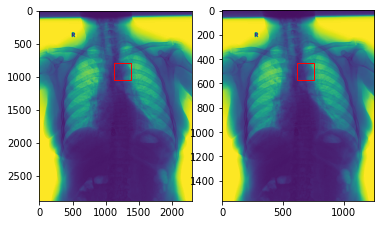

242.0 1470.0 358.0 350.0


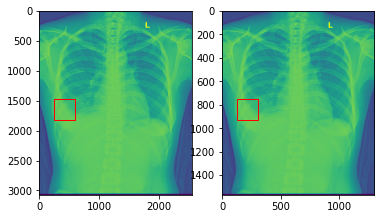

612.0 1361.0 829.0 378.0


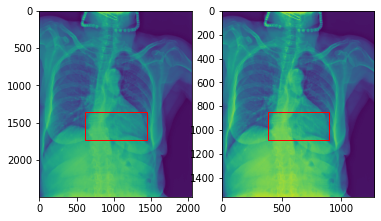

1907.0 1412.0 156.0 135.0


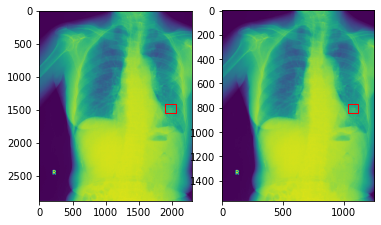

688.0 1248.0 802.0 347.0


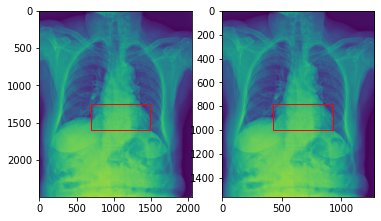

1648.0 270.0 357.0 165.0


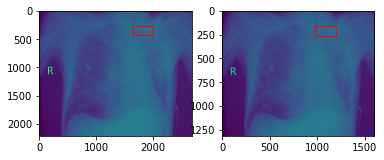

1375.0 469.0 295.0 85.0


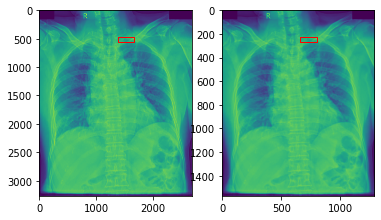

900.0 587.0 305.0 301.0


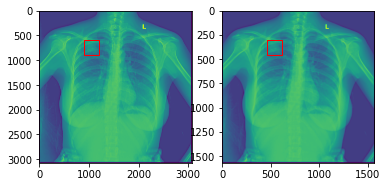

409.0 1831.0 273.0 120.0


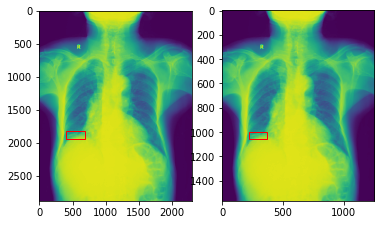

In [23]:
cnt = 0

for index,row in df.iterrows():
    index += 100
    row = df.iloc[index]
    if cnt > 10:
        break
    
    cnt += 1
    img_name = os.path.join(img_dirname, row['image_id'] + ".png")       
    wh_img_name = os.path.join(wh_img_dir, "png_train_" + row['image_id'] + ".png")
    if not os.path.exists(wh_img_name):
        continue
 
    x = row['x_min']
    y = row['y_min']
    w = row['x_max'] -  row['x_min']
    h = row['y_max'] -  row['y_min']
    print(x,y, w, h)
    pil_img_orig = Image.open(img_name)
    pil_img_wp = Image.open(wh_img_name)
    img = np.array(pil_img_orig, dtype=np.uint8)
    img_wp = np.array(pil_img_wp, dtype=np.uint8)
    
    # Create figure and axes
    fig, ax = plt.subplots(1,2)
    
    # Display the image
    ax[0].imshow(img)
    ax[1].imshow(img_wp)
    
    # Create a Rectangle patch
    rect = patches.Rectangle((x, y), w, h, linewidth=1,
                            edgecolor='r', facecolor="none")
    img_w , img_h = pil_img_orig.size
    wp_img_w , wp_img_h = pil_img_wp.size
    x_min = ((row['x_min'])/img_w)*wp_img_w
    x_max = ((row['x_max'])/img_w)*wp_img_w
    y_min = ((row['y_min'])/img_h)*wp_img_h
    y_max = ((row['y_max'])/img_h)*wp_img_h
    w = x_max - x_min
    h = y_max - y_min
    rect_wp = patches.Rectangle((x_min, y_min), w, h, linewidth=1,
                            edgecolor='r', facecolor="none")
    
    # Add the patch to the Axes
    ax[0].add_patch(rect)
    ax[1].add_patch(rect_wp)
    plt.show()

In [4]:
df_new = pd.DataFrame(columns=('image_id', 'class_name', 'class_id', 'rad_id','x_min', 'x_max', 'y_min', 'y_max', 'wp_x_min', 'wp_x_max', 'wp_y_min','wp_y_max'))
img_dirname = "/data6/rajivporana_scratch/vindr_data/png_train/"
wh_img_dir = "/data6/rajivporana_scratch/vindr_data/wh_proper_train/"
wh_img_dir2 = "/data6/rajivporana_scratch/vindr_bbox/dataset/whatsapp_subset_train/whatsapp_images/"
for index,row in df.iterrows():
    row_new = {}
    flag = 1
    img_name = os.path.join(img_dirname, row['image_id'] + ".png")       
    wh_img_name = os.path.join(wh_img_dir, "png_train_" + row['image_id'] + ".png")
    if not os.path.exists(wh_img_name):
        wh_img_name = os.path.join(wh_img_dir2, row['image_id'] + ".png")
        if not os.path.exists(wh_img_name):
            flag = 0
    if flag == 0:        
        continue
 
    x = row['x_min']
    y = row['y_min']
    w = row['x_max'] -  row['x_min']
    h = row['y_max'] -  row['y_min']
    print(x,y, w, h)
    pil_img_orig = Image.open(img_name)
    pil_img_wp = Image.open(wh_img_name)
    img = np.array(pil_img_orig, dtype=np.uint8)
    img_wp = np.array(pil_img_wp, dtype=np.uint8)
 
    img_w , img_h = pil_img_orig.size
    wp_img_w , wp_img_h = pil_img_wp.size
    wp_x_min = ((row['x_min'])/img_w)*wp_img_w
    wp_x_max = ((row['x_max'])/img_w)*wp_img_w
    wp_y_min = ((row['y_min'])/img_h)*wp_img_h
    wp_y_max = ((row['y_max'])/img_h)*wp_img_h
    row_new['image_id'] = row['image_id']
    row_new['class_name'] = row['class_name']
    row_new['class_id'] = row['class_id']
    row_new['rad_id'] = row['rad_id']
  
    row_new['x_min'] = row['x_min']
    row_new['x_max'] = row['x_max']
    row_new['y_min'] = row['y_min']
    row_new['y_max'] = row['y_max']
 
    row_new['wp_x_min'] = wp_x_min
    row_new['wp_x_max'] = wp_x_max
    row_new['wp_y_min'] = wp_y_min
    row_new['wp_y_max'] = wp_y_max
    df_new = pd.concat([df_new, pd.DataFrame([row_new])], ignore_index=True)

1264.0 743.0 347.0 276.0
1329.0 743.0 192.0 215.0
1292.0 554.0 185.0 251.0
1390.0 878.0 226.0 285.0
2233.0 1536.0 285.0 291.0
1898.0 850.0 503.0 1224.0
1656.0 1510.0 907.0 1013.0
862.0 1829.0 1101.0 356.0
531.0 938.0 319.0 226.0
1909.0 1696.0 117.0 237.0
796.0 1078.0 54.0 51.0
1250.0 643.0 383.0 360.0
2123.0 922.0 110.0 88.0
1244.0 522.0 367.0 310.0
1544.0 962.0 466.0 1032.0
1468.0 1616.0 230.0 196.0
1972.0 401.0 278.0 173.0
1426.0 916.0 407.0 536.0
378.0 899.0 25.0 30.0
1519.0 933.0 253.0 200.0
285.0 1986.0 138.0 235.0
2154.0 855.0 537.0 417.0
1333.0 757.0 273.0 361.0
1144.0 338.0 289.0 102.0
583.0 696.0 267.0 178.0
969.0 950.0 43.0 50.0
857.0 1143.0 383.0 319.0
1206.0 724.0 243.0 318.0
1533.0 1113.0 349.0 882.0
881.0 546.0 231.0 1003.0
611.0 1305.0 975.0 358.0
752.0 540.0 769.0 1149.0
862.0 513.0 480.0 216.0
108.0 1810.0 132.0 310.0
2243.0 1742.0 47.0 55.0
713.0 1634.0 78.0 61.0
354.0 2213.0 142.0 149.0
1060.0 1688.0 1196.0 355.0
1078.0 803.0 269.0 320.0
1183.0 1238.0 1107.0 500.0
59

In [7]:
df_new

,image_id,class_name,class_id,rad_id,x_min,x_max,y_min,y_max,wp_x_min,wp_x_max,wp_y_min,wp_y_max
0,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,1611.0,743.0,1019.0,687.409722,876.121094,404.264236,554.435069
1,d3637a1935a905b3c326af31389cb846,Aortic enlargement,0,R10,1329.0,1521.0,743.0,958.0,722.759115,827.175781,404.264236,521.245139
2,321c111713c3ee5385db0effb54ff568,Aortic enlargement,0,R8,1292.0,1477.0,554.0,805.0,702.637153,803.246962,301.429861,437.998264
3,fb8e11c6b2886b2d41b379e0598669b9,Aortic enlargement,0,R10,1390.0,1616.0,878.0,1163.0,755.93316,878.840278,477.717361,632.785069
4,be1bb194dfb986bf7554b491852b8901,Lung Opacity,7,R9,2233.0,2518.0,1536.0,1827.0,1163.020833,1311.458333,800.0,951.5625
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,c75f825862144dbdff940d9c4ecccde8,Aortic enlargement,0,R8,1550.0,1890.0,608.0,1053.0,816.800292,995.969388,320.421607,554.940711
8803,2860567dbd5d3f2597072e0b0e45ccd6,Lung Opacity,7,R8,253.0,771.0,1626.0,1966.0,140.555556,428.333333,903.333333,1092.222222
8804,09b9674023305cb9a0acb367600efffa,Lung Opacity,7,R10,968.0,1331.0,1020.0,1385.0,494.398438,679.797852,520.957031,707.37793
8805,66332eb5425bcdc6854aae970cc656b9,Nodule/Mass,8,R8,2161.0,2308.0,1600.0,1758.0,1166.616144,1245.974114,863.9892,949.308134
